# Testing if there is purchase branch may have any impact on type of customer. RESULT: No favourable information

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import os

In [10]:
input_file_path = '../data/raw/train_data.csv'
df = pd.read_csv(input_file_path)
df['SalesDate'] = pd.to_datetime(df['SalesDate'])

In [11]:
df.columns

Index(['Unnamed: 0', 'BranchName', 'Ship2City', 'Ship2State', 'OrderNumber',
       'InvoiceNumber', 'LineNumber', 'OrderDate', 'SalesDate',
       'SalesPersonID', 'SalesPersonName', 'ProductID', 'ProductGroupID',
       'CustomerID', 'CustomerName', 'ExtPrice', 'ExtCost', 'SalesQty',
       'UnitPrice', 'UnitCost', 'UOM', 'UnitSize', 'Month', 'Year', 'Profit',
       'ProfitMargin', 'ProfitCost_Ratio', 'customer_alias'],
      dtype='object')

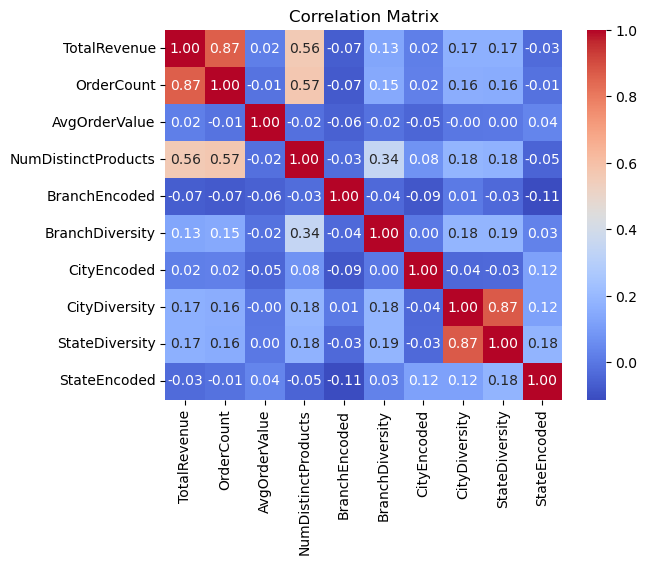

                     TotalRevenue  OrderCount  AvgOrderValue  \
TotalRevenue             1.000000    0.865257       0.020242   
OrderCount               0.865257    1.000000      -0.012242   
AvgOrderValue            0.020242   -0.012242       1.000000   
NumDistinctProducts      0.559154    0.570339      -0.019692   
BranchEncoded           -0.067373   -0.073848      -0.058147   
BranchDiversity          0.131184    0.145870      -0.015501   
CityEncoded              0.018387    0.023651      -0.047306   
CityDiversity            0.169090    0.160345      -0.000320   
StateDiversity           0.168319    0.155987       0.000903   
StateEncoded            -0.031511   -0.013789       0.038447   

                     NumDistinctProducts  BranchEncoded  BranchDiversity  \
TotalRevenue                    0.559154      -0.067373         0.131184   
OrderCount                      0.570339      -0.073848         0.145870   
AvgOrderValue                  -0.019692      -0.058147        -0.0

In [12]:
# Encode categorical variables to numerical values
df["BranchEncoded"] = df["BranchName"].astype("category").cat.codes
df["CityEncoded"] = df["Ship2City"].astype("category").cat.codes
df["StateEncoded"] = df["Ship2State"].astype("category").cat.codes

# Aggregate per customer
customer_metrics = df.groupby("CustomerID").agg(
    TotalRevenue=("ExtPrice", "sum"),
    OrderCount=("OrderNumber", "nunique"),
    AvgOrderValue=("ExtPrice", "mean"),
    NumDistinctProducts=("ProductID", "nunique"),
    BranchEncoded=("BranchEncoded", "first"),  # Assuming customers mainly buy from one branch
    BranchDiversity=("BranchEncoded", "nunique"),
    CityEncoded=("CityEncoded", "first"),
    CityDiversity=("CityEncoded", "nunique"),
    StateDiversity=("StateEncoded", "nunique"),
    StateEncoded=("StateEncoded", "first")
).reset_index()

# Correlation Analysis
correlation_matrix = customer_metrics.drop(columns=["CustomerID"]).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()
print(correlation_matrix)

13 unique branches are there in the data provided

In [13]:
df["BranchName"].nunique()

13

In [14]:

# Aggregate revenue per branch
branch_revenue = df.groupby("BranchName")["ExtPrice"].sum().reset_index()
branch_revenue = branch_revenue.sort_values(by="ExtPrice", ascending=False)
top_branches = branch_revenue.head(5)  # Adjust the number of top branches as needed

# Aggregate revenue per customer
customer_revenue = df.groupby("CustomerID").agg(
    TotalRevenue=("ExtPrice", "sum"),
    BranchName=("BranchName", lambda x: x.mode()[0])  # Most common branch for the customer
).reset_index()

# Identify top customers
top_customers = customer_revenue.sort_values(by="TotalRevenue", ascending=False).head(50)  # Adjust as needed

# Check overlap
top_customers_in_top_branches = top_customers[top_customers["BranchName"].isin(top_branches["BranchName"])]

#Calculate percentage of top customers in top branches
percentage_top_customers_in_top_branches = (len(top_customers_in_top_branches) / len(top_customers)) * 100

# Display results
print(f"Percentage of top customers belonging to top branches: {percentage_top_customers_in_top_branches:.2f}%")
print(f"Out of {len(top_customers)} top customers, {len(top_customers_in_top_branches)} are from top branches.")
# print("\nTop Customers in Top Branches:")
# print(top_customers_in_top_branches)


Percentage of top customers belonging to top branches: 78.00%
Out of 50 top customers, 39 are from top branches.


In [15]:
# Group by BranchName and aggregate customer IDs
customers_per_branch = df.groupby('BranchName')['CustomerID'].unique().reset_index()

# Filter for top branches
customers_in_top_branches = customers_per_branch[customers_per_branch['BranchName'].isin(top_branches['BranchName'])]

# Display results
for index, row in customers_in_top_branches.iterrows():
    branch_customers = set(row['CustomerID'])
    top_customers_in_branch = branch_customers.intersection(set(top_customers['CustomerID']))
    percentage_top_customers = (len(top_customers_in_branch) / len(branch_customers)) * 100
    print(f"Branch: {row['BranchName']}")
    print(f"Customers: {', '.join(row['CustomerID'])}")
    print(f"Percentage of top customers in {row['BranchName']}: {percentage_top_customers:.2f}%\n")


Branch: ADKINSFURT BRANCH
Customers: CUST2, CUST169, CUST188, CUST189, CUST199, CUST204, CUST263, CUST291, CUST168, CUST322, CUST351, CUST379, CUST13, CUST399, CUST509, CUST528, CUST589, CUST593, CUST598, CUST599, CUST600, CUST609, CUST651, CUST658, CUST684, CUST741, CUST114, CUST751, CUST1022, CUST1025, CUST309
Percentage of top customers in ADKINSFURT BRANCH: 9.68%

Branch: EAST ELIZABETH BRANCH
Customers: CUST25, CUST27, CUST9, CUST159, CUST156, CUST26, CUST250, CUST265, CUST67, CUST81, CUST273, CUST276, CUST286, CUST88, CUST320, CUST97, CUST345, CUST347, CUST359, CUST362, CUST365, CUST368, CUST369, CUST431, CUST453, CUST99, CUST467, CUST474, CUST50, CUST478, CUST53, CUST480, CUST113, CUST495, CUST496, CUST498, CUST522, CUST441, CUST501, CUST48, CUST79, CUST556, CUST31, CUST594, CUST173, CUST625, CUST628, CUST645, CUST669, CUST445, CUST98, CUST692, CUST700, CUST702, CUST83, CUST102, CUST730, CUST370, CUST737, CUST51, CUST695, CUST742, CUST745, CUST752, CUST28, CUST96, CUST718, CUST5

In [16]:
# Group by BranchName and get unique customer IDs as sets
customers_per_branch = df.groupby('BranchName')['CustomerID'].apply(set).reset_index()

# Filter for only top branches
customers_in_top_branches = customers_per_branch[customers_per_branch['BranchName'].isin(top_branches['BranchName'])]

# Display results
for index, row in customers_in_top_branches.iterrows():
    branch_customers = row['CustomerID']  # Already a set
    top_customers_in_branch = branch_customers.intersection(set(top_customers['CustomerID']))
    
    # Avoid division by zero
    if len(branch_customers) == 0:
        percentage_top_customers = 0
    else:
        percentage_top_customers = (len(top_customers_in_branch) / len(branch_customers)) * 100
    
    print(f"Branch: {row['BranchName']}")
    print(f"Total Customers: {len(branch_customers)}")
    print(f"Top Customers in Branch: {len(top_customers_in_branch)}")
    print(f"Percentage of top customers in {row['BranchName']}: {percentage_top_customers:.2f}%\n")


Branch: ADKINSFURT BRANCH
Total Customers: 31
Top Customers in Branch: 3
Percentage of top customers in ADKINSFURT BRANCH: 9.68%

Branch: EAST ELIZABETH BRANCH
Total Customers: 174
Top Customers in Branch: 9
Percentage of top customers in EAST ELIZABETH BRANCH: 5.17%

Branch: FOSTERHAVEN BRANCH
Total Customers: 47
Top Customers in Branch: 5
Percentage of top customers in FOSTERHAVEN BRANCH: 10.64%

Branch: JOHNHAVEN BRANCH
Total Customers: 294
Top Customers in Branch: 27
Percentage of top customers in JOHNHAVEN BRANCH: 9.18%

Branch: WEST CHRISTOPHERTON BRANCH
Total Customers: 550
Top Customers in Branch: 16
Percentage of top customers in WEST CHRISTOPHERTON BRANCH: 2.91%

